# QuakeXNet · Mt Rainier Catalog Diagnostic Notebook

Interactive workflow to diagnose missed PNSN events, validate clustering, and audit the master catalog.

**Sections:**
1. Setup & data loading
2. PNSN catalog: distance computation & filtering
3. Master catalog overview
4. Recall analysis (distance × tolerance)
5. Missed event classification (correct / confused / ambiguous / missed)
6. Diagnostic: trace a single missed event through all pipelines
7. Co-association check against raw station files
8. V1 vs V3 catalog comparison
9. Master catalog audit (where did missed events end up?)

## 1. Setup & data loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from math import radians, sin, cos, sqrt, atan2
from datetime import timedelta
import glob
import os

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)
sns.set_style('whitegrid')

# ── PATHS ─ EDIT THESE FOR YOUR ENVIRONMENT ──────────────────────────────────
PNSN_CSV     = '../data/px_su_2010_to_22_APR_2026.csv'
MC_PATH      = '../data/master_catalog.parquet'                # v1 catalog
MC_V3_PATH   = '../logs/mt_rainier_common_detections_v3'        # v3 daily CSVs
STATION_DIR  = '../logs/mt_rainier_detections'                  # raw per-station files
STATION_META = '../data/station_metadata.csv'                   # if you have it; else use STATIONS dict

# ── CONSTANTS ────────────────────────────────────────────────────────────────
RAINIER_LAT = 46.852947
RAINIER_LON = -121.760424
WIN_S       = 100   # QuakeXNet detection window
TOL_S       = 60    # default time tolerance for matching
GAP_S       = 20    # co-association gap

In [2]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1)*cos(lat2)*sin(dlon/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1-a))

# Mt Rainier station list (from station_metadata.csv extract)
STATIONS = {
    'ARAT':(46.788755,-121.852537),'CARB':(46.98832,-122.00541),
    'CRBN':(46.988131,-121.961063),'GTWY':(46.740163,-121.916765),
    'KAUT':(46.730263,-121.85739),'MIRR':(46.800468,-121.837353),
    'OBSR':(46.899719,-121.815331),'OPCH':(46.731319,-121.571171),
    'PANH':(46.859032,-121.642592),'PARA':(46.786442,-121.742149),
    'PR01':(46.91039,-122.03777),'PR02':(46.918305,-122.048639),
    'PR03':(46.903438,-122.032271),'PR04':(46.929694,-121.988976),
    'PR05':(46.841649,-121.948912),'RUSH':(46.90306,-121.94439),
    'SIFT':(46.867092,-121.953246),'SR41':(46.88668,-121.536642),
    'STYX':(46.963747,-122.080535),'TRON':(46.99766,-122.174511),
    'VOIT':(46.96633,-121.9834),'ASF':(46.75988,-122.027771),
    'CMK':(46.934479,-121.229782),'CMM':(46.490829,-122.013321),
    'FMW':(46.941399,-121.670998),'GHW':(47.041489,-122.273727),
    'GLK':(46.557499,-121.610733),'GRL':(46.81403,-121.328072),
    'GSM':(47.20388,-121.796043),'LMW':(46.667831,-122.292549),
    'LO2':(46.750599,-121.809601),'LON':(46.750599,-121.809601),
    'MHL':(46.88221,-122.065231),'MUP':(46.839119,-121.126472),
    'PAK':(46.84132,-122.304268),'PCEP':(47.1114,-122.29122),
    'PCMD':(46.888962,-122.301483),'PUPY':(46.49542,-122.14613),
    'RCM':(46.83564,-121.732979),'RCS':(46.870831,-121.732307),
    'RER':(46.81905,-121.842133),'RSH':(46.812092,-121.529671),
    'RSU':(46.853161,-121.764259),'RVC':(46.94408,-121.97419),
    'RVN':(47.027222,-121.337837),'SPFR':(46.94787,-122.35675),
    'STAR':(46.850849,-121.792953),'STOR':(47.188099,-121.9888),
    'TEHA':(47.12795,-122.1963),'WCR':(46.61396,-121.767754),
    'WI2':(47.136108,-121.382309),'WPEQ':(46.613279,-121.404485),
    'WPS':(46.625,-121.388031),'WPW':(46.698639,-121.537338),
    'XTL':(46.929779,-121.494476)
}
STATION_DIST = {k: haversine(v[0], v[1], RAINIER_LAT, RAINIER_LON) for k, v in STATIONS.items()}
print(f'{len(STATIONS)} stations loaded, distances range '
      f'{min(STATION_DIST.values()):.1f}–{max(STATION_DIST.values()):.1f} km')

55 stations loaded, distances range 0.3–49.5 km


## 2. PNSN catalog: distance & filtering

In [3]:
pnsn = pd.read_csv(PNSN_CSV)
pnsn_ev = pnsn.drop_duplicates(subset='evid').copy()
pnsn_ev['orig_dt_utc'] = pd.to_datetime(pnsn_ev['orig_time_true'], format='mixed', utc=True)

def get_dist(row):
    if row['lat'] != 0 and row['lon'] != 0:
        return haversine(row['lat'], row['lon'], RAINIER_LAT, RAINIER_LON)
    return STATION_DIST.get(row['sta'], np.nan)

pnsn_ev['dist_km'] = pnsn_ev.apply(get_dist, axis=1)
pnsn_ev['year']  = pnsn_ev['orig_dt_utc'].dt.year
pnsn_ev['month'] = pnsn_ev['orig_dt_utc'].dt.month
pnsn_ev['hour']  = pnsn_ev['orig_dt_utc'].dt.hour

pnsn_70  = pnsn_ev[pnsn_ev['dist_km'] <= 70].copy()
pnsn_100 = pnsn_ev[pnsn_ev['dist_km'] <= 100].copy()

print(f'PNSN total unique events:      {len(pnsn_ev):>6}')
print(f'PNSN within 100 km of Rainier: {len(pnsn_100):>6}')
print(f'PNSN within  70 km of Rainier: {len(pnsn_70):>6}')
print()
print('Within 70 km by type:')
print(pnsn_70['etype'].value_counts())

PNSN total unique events:       14754
PNSN within 100 km of Rainier:   7860
PNSN within  70 km of Rainier:   4115

Within 70 km by type:
etype
su    3282
px     833
Name: count, dtype: int64


## 3. Master catalog overview

In [4]:
mc = pd.read_parquet(MC_PATH)
print(f'Master catalog: {len(mc):,} clusters')
print(f'Date range:     {mc["rounded_start"].min()} → {mc["rounded_start"].max()}')
print()
print('Class distribution:')
print(mc['most_common_class'].value_counts())
print()
print('Confidence flags:')
print(f'  high_confidence: {mc["high_confidence"].sum():>7,}')
print(f'  ambiguous:       {mc["ambiguous_class"].sum():>7,}')
print(f'  low_confidence:  {mc["low_confidence"].sum():>7,}')

Master catalog: 738,781 clusters
Date range:     2010-01-01 00:00:50.000400+00:00 → 2026-03-11 23:43:32.100000+00:00

Class distribution:
most_common_class
su    442664
eq    226149
px     69968
Name: count, dtype: int64

Confidence flags:
  high_confidence: 148,978
  ambiguous:       123,578
  low_confidence:  154,871


Events per day in MC:
count    5908.000000
mean      125.047563
std        90.978113
min         1.000000
25%        61.000000
50%        98.000000
75%       160.000000
max       577.000000
dtype: float64

Days with <10 events:     76
Days with <50 events:   1010
Days with ≥100 events:  2889


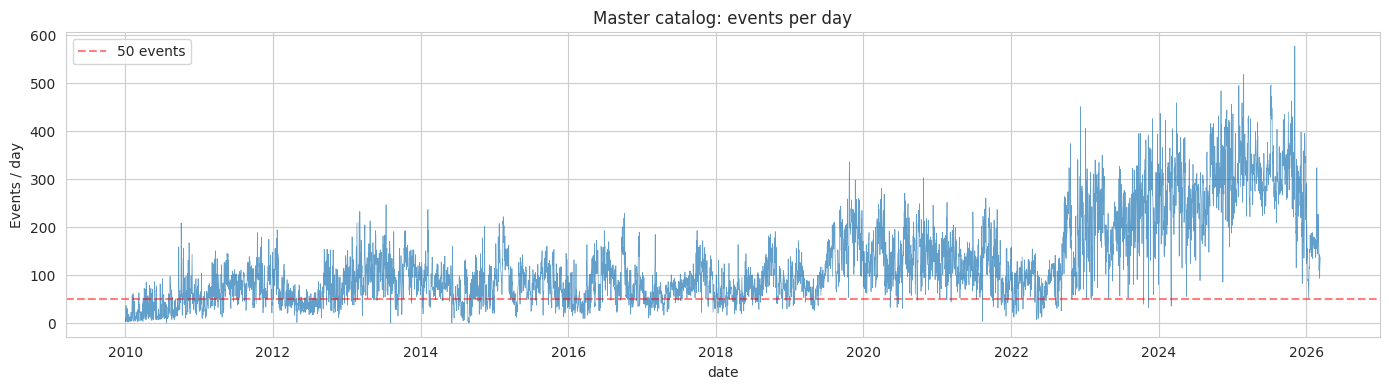

In [5]:
# Coverage diagnostic — how many events per day?
events_per_day = mc.groupby('date').size()
print('Events per day in MC:')
print(events_per_day.describe())
print()
print(f'Days with <10 events:  {(events_per_day < 10).sum():>5}')
print(f'Days with <50 events:  {(events_per_day < 50).sum():>5}')
print(f'Days with ≥100 events: {(events_per_day >= 100).sum():>5}')

# Visualize coverage over time
fig, ax = plt.subplots(figsize=(14, 4))
events_per_day.plot(ax=ax, lw=0.5, alpha=0.7)
ax.set_title('Master catalog: events per day')
ax.set_ylabel('Events / day')
ax.axhline(50, color='red', ls='--', alpha=0.5, label='50 events')
ax.legend()
plt.tight_layout()

## 4. Recall analysis (distance × time tolerance)

For each (distance, tolerance) pair, what fraction of PNSN events does the master catalog detect?

Computing SU recall...
Computing PX recall...


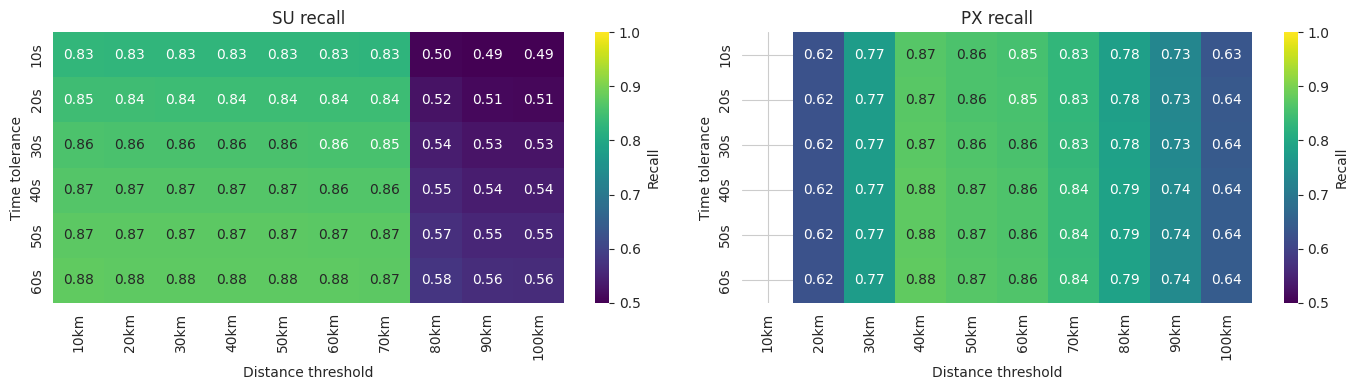

In [6]:
# Pre-sort MC times by class for fast searchsorted
mc_su = np.sort(mc[mc['most_common_class']=='su']['rounded_start'].values.astype('int64'))
mc_px = np.sort(mc[mc['most_common_class']=='px']['rounded_start'].values.astype('int64'))
mc_eq = np.sort(mc[mc['most_common_class']=='eq']['rounded_start'].values.astype('int64'))
mc_all = np.sort(mc['rounded_start'].values.astype('int64'))
WIN_NS = int(WIN_S * 1e9)

def event_matched(pnsn_t_ns, mc_sorted, tol_ns):
    """Does PNSN time fall within any [mc_start - tol, mc_start + WIN + tol]?"""
    lo = pnsn_t_ns - WIN_NS - tol_ns
    hi = pnsn_t_ns + tol_ns
    return np.searchsorted(mc_sorted, hi, 'right') > np.searchsorted(mc_sorted, lo)

def recall_matrix(pnsn_subset, mc_sorted, dist_bins, tols):
    out = np.zeros((len(tols), len(dist_bins)))
    for i, tol in enumerate(tols):
        tol_ns = int(tol * 1e9)
        for j, dmax in enumerate(dist_bins):
            sub = pnsn_subset[pnsn_subset['dist_km'] <= dmax]
            if not len(sub):
                out[i,j] = np.nan; continue
            t_arr = sub['orig_dt_utc'].values.astype('int64')
            matched = sum(1 for t in t_arr if event_matched(int(t), mc_sorted, tol_ns))
            out[i,j] = matched / len(sub)
    return out

dist_bins = list(range(10, 101, 10))
tols      = list(range(10, 61, 10))

su_pnsn = pnsn_100[pnsn_100['etype']=='su']
px_pnsn = pnsn_100[pnsn_100['etype']=='px']

print('Computing SU recall...')
su_recall = recall_matrix(su_pnsn, mc_su, dist_bins, tols)
print('Computing PX recall...')
px_recall = recall_matrix(px_pnsn, mc_px, dist_bins, tols)

# Display heatmaps
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, mat, title in [(axes[0], su_recall, 'SU recall'), (axes[1], px_recall, 'PX recall')]:
    sns.heatmap(mat, annot=True, fmt='.2f', cmap='viridis',
                xticklabels=[f'{d}km' for d in dist_bins],
                yticklabels=[f'{t}s' for t in tols],
                vmin=0.5, vmax=1.0, ax=ax, cbar_kws={'label': 'Recall'})
    ax.set_xlabel('Distance threshold')
    ax.set_ylabel('Time tolerance')
    ax.set_title(title)
plt.tight_layout()

## 5. Classify each PNSN event: correct / confused / ambiguous / missed

For each PNSN event within 70 km, determine what the ML model said:

In [7]:
TOL_NS_60 = int(60 * 1e9)

def classify_outcome(t_ns, etype):
    msu  = event_matched(t_ns, mc_su,  TOL_NS_60)
    mpx  = event_matched(t_ns, mc_px,  TOL_NS_60)
    meq  = event_matched(t_ns, mc_eq,  TOL_NS_60)
    many = event_matched(t_ns, mc_all, TOL_NS_60)
    if not many: return 'missed'
    if etype == 'su':
        if msu and not mpx and not meq: return 'correct_su'
        if mpx and not msu:             return 'confused_px'
        if meq and not msu:             return 'confused_eq'
        if msu and mpx:                 return 'ambiguous_su_px'
        if msu and meq:                 return 'ambiguous_su_eq'
        return 'other'
    else:
        if mpx and not msu and not meq: return 'correct_px'
        if msu and not mpx:             return 'confused_su'
        if meq and not mpx:             return 'confused_eq'
        if mpx and msu:                 return 'ambiguous_px_su'
        if mpx and meq:                 return 'ambiguous_px_eq'
        return 'other'

pnsn_70 = pnsn_70.copy()
pnsn_70['t_ns'] = pnsn_70['orig_dt_utc'].values.astype('int64')
pnsn_70['ml_outcome'] = pnsn_70.apply(lambda r: classify_outcome(int(r['t_ns']), r['etype']), axis=1)

print('=== SU events (within 70 km) ===')
print(pnsn_70[pnsn_70['etype']=='su']['ml_outcome'].value_counts())
print()
print('=== PX events (within 70 km) ===')
print(pnsn_70[pnsn_70['etype']=='px']['ml_outcome'].value_counts())

=== SU events (within 70 km) ===
ml_outcome
correct_su         2495
ambiguous_su_px     254
missed              244
confused_px         138
ambiguous_su_eq     122
confused_eq          29
Name: count, dtype: int64

=== PX events (within 70 km) ===
ml_outcome
correct_px         390
ambiguous_px_su    270
missed              63
confused_su         60
ambiguous_px_eq     37
confused_eq         13
Name: count, dtype: int64


Saved 307 missed events → missed_events.csv


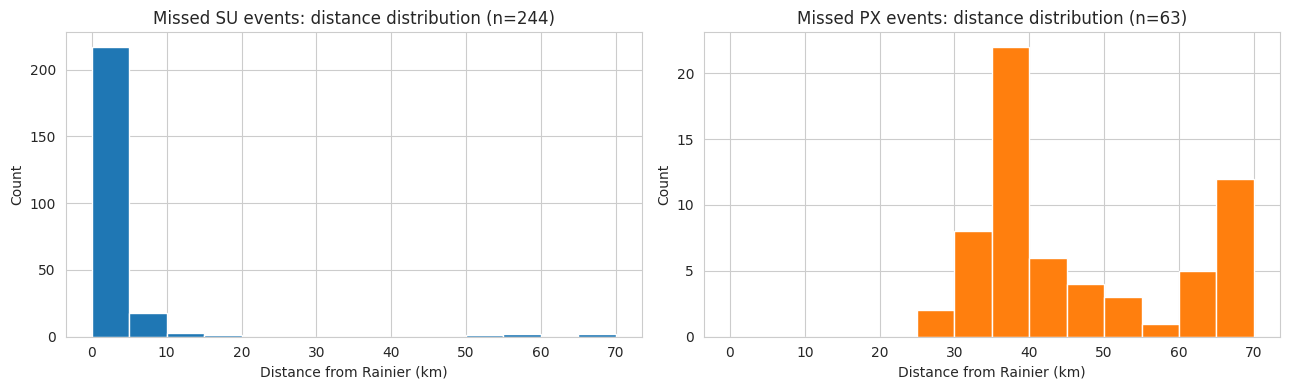

In [8]:
# Save the missed events for downstream investigation
missed = pnsn_70[pnsn_70['ml_outcome'] == 'missed'].copy()
missed.to_csv('missed_events.csv', index=False)
print(f'Saved {len(missed)} missed events → missed_events.csv')

# Distance breakdown of missed events
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, etype, color in [(axes[0], 'su', 'tab:blue'), (axes[1], 'px', 'tab:orange')]:
    sub = missed[missed['etype']==etype]
    ax.hist(sub['dist_km'], bins=np.arange(0, 75, 5), color=color, edgecolor='white')
    ax.set_xlabel('Distance from Rainier (km)')
    ax.set_ylabel('Count')
    ax.set_title(f'Missed {etype.upper()} events: distance distribution (n={len(sub)})')
plt.tight_layout()

## 6. Diagnostic: trace a single missed event

Pick one missed PNSN event and walk through every step to see where it gets lost. Edit `TARGET_EVID` to investigate any specific event.

In [9]:
# Pick a missed event to investigate
TARGET_EVID = missed.iloc[0]['evid']   # or paste a specific evid

target = missed[missed['evid'] == TARGET_EVID].iloc[0]
t_target = target['orig_dt_utc']

print(f'─── TARGET EVENT ───────────────────────────────────────')
print(f'evid:      {target["evid"]}')
print(f'etype:     {target["etype"]}')
print(f'time UTC:  {t_target}')
print(f'dist:      {target["dist_km"]:.2f} km from Rainier summit')
print(f'station:   {target["sta"]}')
print(f'lat/lon:   {target["lat"]}, {target["lon"]}')

─── TARGET EVENT ───────────────────────────────────────
evid:      10788193
etype:     px
time UTC:  2010-01-14 23:07:01.360000+00:00
dist:      26.74 km from Rainier summit
station:   RER
lat/lon:   46.961, -122.0748333


In [10]:
# Step 1: what does the master catalog have on this date?
date_str = t_target.strftime('%Y-%m-%d')
mc_day = mc[mc['date'].astype(str) == date_str].sort_values('rounded_start')
print(f'Master catalog has {len(mc_day)} events on {date_str}')
if len(mc_day):
    print()
    print('Hours covered:')
    print(mc_day['rounded_start'].dt.hour.value_counts().sort_index())
    print()
    print('Events near target time (±30 min):')
    mask = (mc_day['rounded_start'] >= t_target - pd.Timedelta(minutes=30)) & \
           (mc_day['rounded_start'] <= t_target + pd.Timedelta(minutes=30))
    print(mc_day[mask][['rounded_start','most_common_class','num_stations','vote_margin']])

Master catalog has 5 events on 2010-01-14

Hours covered:
rounded_start
0    4
1    1
Name: count, dtype: int64

Events near target time (±30 min):
Empty DataFrame
Columns: [rounded_start, most_common_class, num_stations, vote_margin]
Index: []


In [11]:
# Step 2: what do the raw station files show on this date around the target time?
def parse_iso(s):
    return pd.Timestamp(str(s).rstrip('Z'), tz='UTC')

def load_day_station_files(base_path, dt):
    date_str = dt.strftime('%Y%m%d')
    folder = os.path.join(base_path, f'{date_str}_0000_{date_str}_2359')
    files = glob.glob(os.path.join(folder, '*_events.csv'))
    dfs = []
    for f in files:
        try:
            df = pd.read_csv(f)
            if not df.empty:
                dfs.append(df)
        except Exception as e:
            print(f'  Skip {f}: {e}')
    if not dfs: return pd.DataFrame()
    return pd.concat(dfs, ignore_index=True)

day_df = load_day_station_files(STATION_DIR, t_target)
if day_df.empty:
    print(f'No raw station files found for {date_str}')
else:
    day_df['_start'] = day_df['start_time'].apply(parse_iso)
    print(f'Raw station files: {len(day_df)} detections across {day_df["station"].nunique()} stations')
    
    lo = t_target - pd.Timedelta(seconds=TOL_S)
    hi = t_target + pd.Timedelta(seconds=WIN_S + TOL_S)
    nearby = day_df[(day_df['_start'] >= lo) & (day_df['_start'] <= hi)].sort_values('_start')
    
    print(f'\nDetections within [{lo}, {hi}]:')
    if nearby.empty:
        print('  None — model genuinely did not detect this event')
    else:
        print(nearby[['station','class','max_prob','start_time']].to_string())

Raw station files: 308 detections across 7 stations

Detections within [2010-01-14 23:06:01.360000+00:00, 2010-01-14 23:09:41.360000+00:00]:
    station class  max_prob                   start_time
162     RCS    px  0.675708  2010-01-14T23:06:09.160000Z
35      LON    px  0.926794  2010-01-14T23:06:27.472000Z
5       LO2    px  0.968555  2010-01-14T23:06:49.160000Z


In [13]:
# Step 3: co-association check — would this cluster as a multi-station event?
if not day_df.empty:
    nearby = day_df[(day_df['_start'] >= lo) & (day_df['_start'] <= hi)].copy()
    
    if len(nearby) >= 2:
        starts_ns = nearby['_start'].astype('int64').values
        keep = np.zeros(len(starts_ns), dtype=bool)
        for i in range(len(starts_ns)):
            diffs_s = np.abs(starts_ns - starts_ns[i]) / 1e9
            diffs_s[i] = np.inf
            if diffs_s.min() <= (WIN_S + GAP_S):
                keep[i] = True
        co_associated = nearby[keep]
        unique_stations = co_associated['station'].nunique()
        
        print(f'Co-associated detections: {len(co_associated)}')
        print(f'Unique stations:          {unique_stations}')
        if unique_stations >= 3:
            print('→ This event SHOULD have made it into the master catalog')
            print('→ Class breakdown:')
            print(co_associated['class'].value_counts())
        else:
            print(f'→ Only {unique_stations} stations — below 3-station threshold')

Co-associated detections: 3
Unique stations:          3
→ This event SHOULD have made it into the master catalog
→ Class breakdown:
class
px    3
Name: count, dtype: int64


## 7. Co-association check across all missed events

In [15]:
def check_co_association(origin_utc, day_df, tol_s=TOL_S, win_s=WIN_S, gap_s=GAP_S):
    """Returns dict with n_stations, dominant_class, etc for one event."""
    if day_df.empty:
        return {'n_stations': 0, 'stations': '', 'dominant_class': 'none'}
    
    if '_start' not in day_df.columns:
        day_df = day_df.copy()
        day_df['_start'] = day_df['start_time'].apply(parse_iso)
    
    lo = origin_utc - pd.Timedelta(seconds=tol_s)
    hi = origin_utc + pd.Timedelta(seconds=win_s + tol_s)
    candidates = day_df[(day_df['_start'] >= lo) & (day_df['_start'] <= hi)].copy()
    
    if candidates.empty:
        return {'n_stations': 0, 'stations': '', 'dominant_class': 'none'}
    
    if len(candidates) == 1:
        return {'n_stations': 1, 'stations': candidates['station'].iloc[0],
                'dominant_class': candidates['class'].iloc[0]}
    
    starts_ns = candidates['_start'].astype('int64').values
    keep = np.zeros(len(starts_ns), dtype=bool)
    for i in range(len(starts_ns)):
        diffs_s = np.abs(starts_ns - starts_ns[i]) / 1e9
        diffs_s[i] = np.inf
        if diffs_s.min() <= (win_s + gap_s):
            keep[i] = True
    
    co = candidates[keep]
    if co.empty:
        return {'n_stations': 0, 'stations': '', 'dominant_class': 'none'}
    
    co = co.sort_values('max_prob', ascending=False).drop_duplicates('station')
    return {'n_stations': co['station'].nunique(),
            'stations': '|'.join(sorted(co['station'].unique())),
            'dominant_class': co['class'].mode().iloc[0]}

# Run across all missed events (with day-level caching for speed)
_day_cache = {}
rows = []
for idx, row in missed.iterrows():
    date_key = row['orig_dt_utc'].date()
    if date_key not in _day_cache:
        _day_cache[date_key] = load_day_station_files(STATION_DIR, row['orig_dt_utc'])
    summary = check_co_association(row['orig_dt_utc'], _day_cache[date_key])
    rows.append({**row.to_dict(), **summary})
    if (idx + 1) % 25 == 0:
        print(f'  {idx+1}/{len(missed)}')

missed_check = pd.DataFrame(rows)
print('\nStation count breakdown for missed events:')
print(missed_check.groupby('etype')['n_stations'].describe())

  2225/307
  4650/307
  4850/307
  22125/307
  24875/307
  27650/307
  28175/307
  29475/307
  36500/307
  60900/307
  102575/307
  102825/307
  103225/307

Station count breakdown for missed events:
       count      mean       std  min  25%  50%  75%   max
etype                                                     
px      63.0  2.619048  1.337168  0.0  2.0  3.0  3.0   6.0
su     244.0  2.856557  2.651174  0.0  2.0  3.0  4.0  25.0


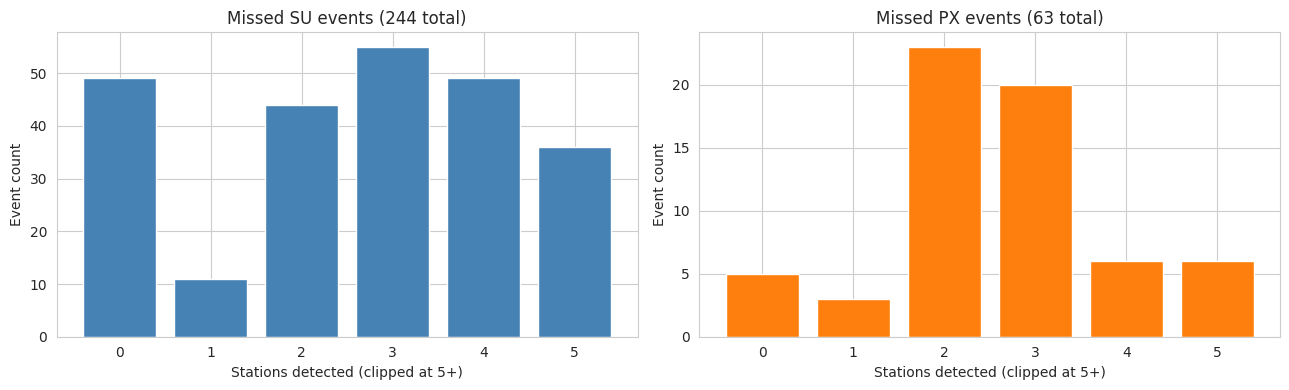

In [16]:
# Save and visualize
missed_check.to_csv('missed_events_station_check.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, etype in zip(axes, ['su', 'px']):
    sub = missed_check[missed_check['etype']==etype]
    counts = sub['n_stations'].clip(upper=5).value_counts().sort_index()
    ax.bar(counts.index.astype(str), counts.values, color='steelblue' if etype=='su' else 'tab:orange')
    ax.set_title(f'Missed {etype.upper()} events ({len(sub)} total)')
    ax.set_xlabel('Stations detected (clipped at 5+)')
    ax.set_ylabel('Event count')
plt.tight_layout()

## 8. V1 vs V3 catalog comparison

In [17]:
# Load v3 catalog (run gen_com_events_v3.py first to build this)
v3_files = sorted(glob.glob(os.path.join(MC_V3_PATH, 'common_*.csv')))
print(f'Found {len(v3_files)} v3 daily catalog files')

if v3_files:
    v3 = pd.concat([pd.read_csv(f) for f in v3_files], ignore_index=True)
    v3['rounded_start'] = pd.to_datetime(v3['rounded_start'], format='mixed', utc=True)
    print(f'V3 catalog: {len(v3):,} clusters')
    print(f'V3 date range: {v3["rounded_start"].min()} → {v3["rounded_start"].max()}')
    print()
    
    # Compare daily counts on overlapping dates
    v1_per_day = mc.groupby(mc['rounded_start'].dt.date).size()
    v3_per_day = v3.groupby(v3['rounded_start'].dt.date).size()
    common_dates = sorted(set(v1_per_day.index) & set(v3_per_day.index))
    
    print(f'Days in both catalogs: {len(common_dates)}')
    if common_dates:
        comp = pd.DataFrame({
            'v1': v1_per_day.loc[common_dates],
            'v3': v3_per_day.loc[common_dates]
        })
        comp['ratio'] = comp['v3'] / comp['v1'].replace(0, np.nan)
        print('\nV1 vs V3 daily count comparison:')
        print(comp.describe())
else:
    print('No v3 catalog yet — run gen_com_events_v3.py first.')

Found 4018 v3 daily catalog files


/tmp/ipykernel_3386957/2316757218.py:6: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  v3 = pd.concat([pd.read_csv(f) for f in v3_files], ignore_index=True)


V3 catalog: 795,455 clusters
V3 date range: 2010-01-01 00:00:50.000400+00:00 → 2020-12-31 23:50:00+00:00

Days in both catalogs: 4012

V1 vs V3 daily count comparison:
                v1           v3        ratio
count  4012.000000  4012.000000  4012.000000
mean     85.713609   198.263958     2.549518
std      48.257087    82.762629     0.683043
min       1.000000     1.000000     1.000000
25%      51.000000   143.000000     2.122780
50%      78.000000   197.000000     2.436034
75%     112.000000   252.000000     2.829786
max     336.000000   441.000000    18.000000


## 9. Master catalog audit

For PNSN events that appear in MC but with a *different* class — these are catalog audit candidates.

In [18]:
# Pull confused events: PNSN says one thing, ML says another
confused_su = pnsn_70[(pnsn_70['etype']=='su') & (pnsn_70['ml_outcome'].isin(['confused_px','confused_eq']))].copy()
confused_px = pnsn_70[(pnsn_70['etype']=='px') & (pnsn_70['ml_outcome'].isin(['confused_su','confused_eq']))].copy()

print(f'SU events ML calls something else: {len(confused_su)}')
print(confused_su['ml_outcome'].value_counts())
print()
print(f'PX events ML calls something else: {len(confused_px)}')
print(confused_px['ml_outcome'].value_counts())

confused_su.to_csv('confused_su_events.csv', index=False)
confused_px.to_csv('confused_px_events.csv', index=False)

SU events ML calls something else: 167
ml_outcome
confused_px    138
confused_eq     29
Name: count, dtype: int64

PX events ML calls something else: 73
ml_outcome
confused_su    60
confused_eq    13
Name: count, dtype: int64


In [19]:
# Augment confused events with the actual ML cluster info
def find_best_mc_match(t_utc, tol_s=60):
    lo = t_utc - pd.Timedelta(seconds=WIN_S + tol_s)
    hi = t_utc + pd.Timedelta(seconds=tol_s)
    matches = mc[(mc['rounded_start'] >= lo) & (mc['rounded_start'] <= hi)]
    if matches.empty: return None
    return matches.sort_values(['num_stations','vote_margin'], ascending=False).iloc[0]

# For each confused PNSN event, get the actual ML cluster
audit_rows = []
for _, row in pd.concat([confused_su, confused_px]).iterrows():
    match = find_best_mc_match(row['orig_dt_utc'])
    if match is not None:
        audit_rows.append({
            'pnsn_evid':         row['evid'],
            'pnsn_class':        row['etype'],
            'pnsn_time':         row['orig_dt_utc'],
            'dist_km':           row['dist_km'],
            'ml_event_id':       match['event_id'],
            'ml_class':          match['most_common_class'],
            'ml_num_stations':   match['num_stations'],
            'ml_vote_margin':    match['vote_margin'],
            'ml_high_conf':      match['high_confidence'],
            'ml_frac_su':        match['frac_su'],
            'ml_frac_px':        match['frac_px'],
            'ml_frac_eq':        match['frac_eq'],
            'ml_time':           match['rounded_start']
        })

audit = pd.DataFrame(audit_rows)
print(f'Audit candidates: {len(audit)}')
print(audit.head(15))
audit.to_csv('catalog_audit_candidates.csv', index=False)

Audit candidates: 240
    pnsn_evid pnsn_class                        pnsn_time   dist_km ml_event_id ml_class  ml_num_stations  ml_vote_margin  ml_high_conf  ml_frac_su  ml_frac_px  ml_frac_eq  \
0    10822353         su 2011-06-30 04:22:40.240000+00:00  3.002790   MR0025527       px                3        0.666667         False    0.333333    0.666667    0.000000   
1    10820433         su        2011-07-06 22:22:00+00:00  2.484635   MR0026122       px                4        0.500000         False    0.500000    0.500000    0.000000   
2    10827483         su 2011-08-30 18:33:03.070000+00:00  2.839048   MR0030388       px                4        0.500000         False    0.500000    0.500000    0.000000   
3    60381631         su 2012-01-10 19:07:17.270000+00:00  1.253056   MR0042134       eq                3        0.333333         False    0.333333    0.333333    0.333333   
4    60382781         su 2012-01-12 11:37:26.519718+00:00  2.917727   MR0042351       px               

---

## Notes & next steps

**Outputs from this notebook:**
- `missed_events.csv` — PNSN events that the model didn't detect at all
- `missed_events_station_check.csv` — for each missed event, how many raw stations actually saw it
- `confused_su_events.csv` / `confused_px_events.csv` — model disagreed on class
- `catalog_audit_candidates.csv` — high-confidence PNSN/ML disagreements worth analyst review

**Diagnosis paths:**
- If section 6 shows a missed event has ≥3 raw-station detections but isn't in MC → clustering bug (run v3)
- If raw-station detections show ≤2 stations → genuine completeness limit
- If raw-station detections classify as `eq` instead of `su` → model class confusion (catalog audit candidate)

In [22]:
# ── DIAGNOSTIC: trace ONE missed event through v3 ──────────────────────────
TARGET_EVID = 60946762  # n_stations=6, dominant_class=su, 2015 (covered by v3)

target = missed_check[missed_check['evid'] == TARGET_EVID].iloc[0]
t_target = pd.to_datetime(target['orig_time_true'], utc=True)

print(f'─── TARGET EVENT ─────────────────────')
print(f'evid:       {target["evid"]}')
print(f'PNSN class: {target["etype"]}')
print(f'time UTC:   {t_target}')
print(f'dist:       {target["dist_km"]:.2f} km')
print(f'Raw station detections: {target["n_stations"]} stations')
print(f'Stations: {target["stations"]}')
print(f'Dominant class in raw: {target["dominant_class"]}')
print()

# Step 1: Load v3 catalog for that day
date_str = t_target.strftime('%Y%m%d')
v3_file = os.path.join(MC_V3_PATH, f'common_{date_str}_0000_to_{date_str}_2359_events.csv')
print(f'Looking for v3 file: {v3_file}')
print(f'Exists: {os.path.exists(v3_file)}')
print()

if os.path.exists(v3_file):
    v3_day = pd.read_csv(v3_file)
    v3_day['rounded_start'] = pd.to_datetime(v3_day['rounded_start'], format='mixed', utc=True)
    print(f'V3 has {len(v3_day)} clusters on {date_str}')
    
    w_lo = t_target - pd.Timedelta(minutes=5)
    w_hi = t_target + pd.Timedelta(minutes=5)
    nearby = v3_day[(v3_day['rounded_start'] >= w_lo) & (v3_day['rounded_start'] <= w_hi)]
    
    print(f'\nV3 clusters within ±5 minutes of target:')
    if nearby.empty:
        print('  NONE')
    else:
        print(nearby[['rounded_start','num_stations','most_common_class','vote_margin','stations']].to_string())
    
    v3_file_2 = os.path.join(MC_V3_PATH, f'common2_{date_str}_0000_to_{date_str}_2359_events.csv')
    if os.path.exists(v3_file_2):
        v3_day_2 = pd.read_csv(v3_file_2)
        v3_day_2['rounded_start'] = pd.to_datetime(v3_day_2['rounded_start'], format='mixed', utc=True)
        nearby_2 = v3_day_2[(v3_day_2['rounded_start'] >= w_lo) & (v3_day_2['rounded_start'] <= w_hi)]
        print(f'\nV3 2-station catalog clusters within ±5 min:')
        if nearby_2.empty:
            print('  NONE')
        else:
            print(nearby_2[['rounded_start','num_stations','most_common_class','vote_margin','stations']].to_string())

─── TARGET EVENT ─────────────────────
evid:       60946762
PNSN class: su
time UTC:   2015-01-11 14:08:44.938936+00:00
dist:       2.84 km
Raw station detections: 6 stations
Stations: FMW|LON|OBSR|PANH|RCM|STAR
Dominant class in raw: su

Looking for v3 file: ../logs/mt_rainier_common_detections_v3/common_20150111_0000_to_20150111_2359_events.csv
Exists: True

V3 has 249 clusters on 20150111

V3 clusters within ±5 minutes of target:
                       rounded_start  num_stations most_common_class  vote_margin                                       stations
162        2015-01-11 14:06:40+00:00             6                su     1.000000  ['LO2', 'LON', 'OBSR', 'PANH', 'RCM', 'STAR']
163 2015-01-11 14:08:40.000043+00:00             3                eq     0.333333                         ['FMW', 'OBSR', 'RCM']
164 2015-01-11 14:11:40.000041+00:00             3                su     0.666667                        ['OBSR', 'RCS', 'STAR']

V3 2-station catalog clusters within ±5 min:
 

In [21]:
missed_check

,evid,prefor,version,etype,arid,orig_time_true,lat,lon,depth,totalarr,nbs,erhor,sdep,orig_commit_time,net,sta,location,seedchan,iphase,quality,traveltime,orig_dt_utc,dist_km,year,month,hour,t_ns,ml_outcome,n_stations,stations,dominant_class
0,10788193,1072543,3,px,10053943,2010-01-14 23:07:01.36,46.961000,-122.074833,-1.28500,7.0,0.0,4.249,0.17,2012-03-07 18:10:56,UW,RER,NaN,EHZ,P,0.50,3.611000,2010-01-14 23:07:01.360000+00:00,26.736365,2010,1,23,1263510421360000000,missed,3,LO2|LON|RCS,px
1,10790463,1074813,3,px,10073423,2010-01-22 20:38:54.87,46.610833,-122.249500,-0.44600,6.0,0.0,0.457,0.05,2012-03-07 18:20:02,UW,LO2,NaN,EHZ,P,0.50,6.290000,2010-01-22 20:38:54.870000+00:00,45.980120,2010,1,20,1264192734870000000,missed,3,LO2|LON|RCS,px
2,10799308,1083718,3,px,10166323,2010-04-29 18:21:39.77,46.922500,-122.113667,6.15200,16.0,4.0,1.815,6.70,2012-03-07 19:20:28,UW,STAR,NaN,EHN,S,0.50,8.861000,2010-04-29 18:21:39.770000+00:00,27.936169,2010,4,18,1272565299770000000,missed,2,LON|STAR,eq
3,10802208,1086628,2,px,10199883,2010-05-10 17:48:39.99,46.785000,-122.647667,3.26600,6.0,0.0,0.666,0.05,2012-03-07 19:52:30,UW,ELK,NaN,EHZ,P,0.80,9.430000,2010-05-10 17:48:39.990000+00:00,67.932547,2010,5,17,1273513719990000000,missed,2,RER|STAR,eq
4,10802413,1086833,3,px,10201743,2010-05-11 20:30:56.07,47.241333,-121.976333,10.04300,10.0,3.0,0.714,0.75,2012-03-07 19:57:50,UW,RER,NaN,EHZ,S,0.50,14.030000,2010-05-11 20:30:56.070000+00:00,46.181085,2010,5,20,1273609856070000000,missed,3,LO2|LON|STAR,px
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
302,62244761,3379348,3,su,18629158,2026-04-20 01:25:40.429406,46.835600,-121.733000,-3.07600,0.0,0.0,NaN,NaN,2026-04-20 18:22:28.436083,UW,RCM,NaN,HHZ,P,0.50,1.000000,2026-04-20 01:25:40.429406+00:00,2.840948,2026,4,1,1776648340429406000,missed,0,,none
303,62244821,3379323,3,su,18628813,2026-04-20 13:18:48.912598,46.835600,-121.733000,-3.54542,0.0,0.0,NaN,NaN,2026-04-20 18:02:55.886828,CC,MILD,NaN,BHZ,P,0.50,2.141465,2026-04-20 13:18:48.912598+00:00,2.840948,2026,4,13,1776691128912598000,missed,0,,none
304,62245671,3379613,3,su,18634188,2026-04-22 15:20:23.662448,46.835600,-121.733000,-3.07600,0.0,0.0,NaN,NaN,2026-04-22 17:17:14.243137,UW,RCM,NaN,HHZ,P,0.25,1.000000,2026-04-22 15:20:23.662448+00:00,2.840948,2026,4,15,1776871223662448000,missed,0,,none
305,62246211,3379683,1,su,18634768,2026-04-22 19:51:48.189999,46.834167,-121.732333,-2.27000,5.0,0.0,4.650,31.61,2026-04-22 20:49:17.295254,CC,PANH,NaN,BHZ,P,0.25,1.773560,2026-04-22 19:51:48.189999+00:00,2.987548,2026,4,19,1776887508189999000,missed,0,,none


In [23]:
# Replicate the recovery script logic exactly for this one event
WIN_NS = int(100 * 1e9)
TOL_NS = int(60 * 1e9)

pnsn_t_ns = int(t_target.value)  # nanoseconds
v3_start_ns = int(pd.Timestamp('2015-01-11 14:06:40+00:00').value)

print(f'PNSN time (ns):     {pnsn_t_ns}')
print(f'V3 start (ns):      {v3_start_ns}')
print(f'Diff (s):           {(pnsn_t_ns - v3_start_ns) / 1e9:.1f}')
print()

lo = pnsn_t_ns - WIN_NS - TOL_NS
hi = pnsn_t_ns + TOL_NS
print(f'Match window lo:    {lo}  =  {pd.Timestamp(lo)}')
print(f'Match window hi:    {hi}  =  {pd.Timestamp(hi)}')
print(f'V3 in window?       {lo <= v3_start_ns <= hi}')

# Now load all v3 clusters and run the actual matching
v3_all_files = sorted(glob.glob(os.path.join(MC_V3_PATH, 'common_*.csv')))
v3_full = pd.concat([pd.read_csv(f) for f in v3_all_files], ignore_index=True)
v3_full['rounded_start'] = pd.to_datetime(v3_full['rounded_start'], format='mixed', utc=True)
v3_t_sorted = np.sort(v3_full['rounded_start'].values.astype('int64'))

idx_lo = np.searchsorted(v3_t_sorted, lo)
idx_hi = np.searchsorted(v3_t_sorted, hi, side='right')
print(f'\nV3 clusters in match window: {idx_hi - idx_lo}')
if idx_hi > idx_lo:
    matched_times = v3_t_sorted[idx_lo:idx_hi]
    for t in matched_times:
        print(f'  {pd.Timestamp(t)}')

PNSN time (ns):     1420985324938936000
V3 start (ns):      1420985200000000000
Diff (s):           124.9

Match window lo:    1420985164938936000  =  2015-01-11 14:06:04.938936
Match window hi:    1420985384938936000  =  2015-01-11 14:09:44.938936
V3 in window?       True


/tmp/ipykernel_3386957/4192071402.py:21: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  v3_full = pd.concat([pd.read_csv(f) for f in v3_all_files], ignore_index=True)



V3 clusters in match window: 2
  2015-01-11 14:06:40
  2015-01-11 14:08:40.000043


In [24]:
# Verify the recovery script's timestamp conversion
import pandas as pd

# Load missed_events.csv exactly as the recovery script does
missed_df = pd.read_csv('missed_events.csv')
missed_df['orig_dt_utc'] = pd.to_datetime(missed_df['orig_time_true'], format='mixed', utc=True)

# Recovery script's conversion
recovery_t_ns = missed_df['orig_dt_utc'].values.astype('int64') * 1000

# Direct conversion (correct way)
direct_t_ns = missed_df['orig_dt_utc'].values.astype('int64')

# Compare for our target event
target_row = missed_df[missed_df['evid'] == 60946762].iloc[0]
print(f'Target evid: {target_row["evid"]}')
print(f'orig_time_true: {target_row["orig_time_true"]}')
print(f'orig_dt_utc:    {target_row["orig_dt_utc"]}')
print()

idx = missed_df[missed_df['evid'] == 60946762].index[0]
print(f'Recovery script t_ns (with *1000): {recovery_t_ns[idx]}')
print(f'Direct t_ns:                       {direct_t_ns[idx]}')
print(f'Difference factor:                 {recovery_t_ns[idx] / direct_t_ns[idx]:.4f}')
print()
print(f'Recovery as datetime: {pd.Timestamp(recovery_t_ns[idx])}')
print(f'Direct as datetime:   {pd.Timestamp(direct_t_ns[idx])}')

Target evid: 60946762
orig_time_true: 2015-01-11 14:08:44.938936
orig_dt_utc:    2015-01-11 14:08:44.938936+00:00

Recovery script t_ns (with *1000): 586031263300525568
Direct t_ns:                       1420985324938936000
Difference factor:                 0.4124

Recovery as datetime: 1988-07-27 18:27:43.300525568
Direct as datetime:   2015-01-11 14:08:44.938936
